# LQ dynamics and impulse responses

**Reader question.** How is the transparent local Brownian model solved and checked,
and what moves gradually after an automation-state displacement?

**Answer in brief.** Around an interior steady state, the model becomes a four-state
linear-quadratic system in productivity, automation, log capital, and the tax rate. A
Riccati solve produces the closed-loop matrix; matrix exponentiation then traces local
conditional-mean dynamics. A separate leading-small-risk calculation decomposes the
risky position into return demand and a fiscal hedge.

The frozen calculation passes its configured algebraic and local path checks, but its
evidence status is **exploratory only**. It is not a global constrained Ramsey solution,
a stationary public-wealth result, or an exact finite-risk welfare result.

## Model and comparison

The local state is

$$
y=(z-\bar z,\;x-\bar x,\;\log(K/\bar K),\;\tau-\bar\tau).
$$

The maintained branch has two OU shocks, smooth full specialization, worker-only
welfare, privately owned domestic capital, one external risky public claim, and a
price-taking world-pricing closure. Capital and the tax level cannot jump; tax speed,
transfers, safe finance, and capital propagate shocks over time. All rates are annual
and horizons are years.

The dynamic figure below begins from a declared inherited automation-state displacement
and switches subsequent shocks off. It uses the publicly tracked closed-loop matrix. It
is not the run's finite-window Brownian innovation and is not a forecast.

## Load the public, hash-traceable export

Every source used in the compact export is already tracked at the pinned public
upstream commit: the closed-loop matrix, zero-public-net-worth portfolio row, run
summary, corrected findings, and run record. The refresh script verifies each source
hash before rebuilding this file.

In [1]:
import json
from pathlib import Path
from IPython.display import Markdown, display

data_path = next(
    path
    for path in (
        Path("notebooks/data/cs001_lq_snapshot.json"),
        Path("data/cs001_lq_snapshot.json"),
    )
    if path.exists()
)
snapshot = json.loads(data_path.read_text(encoding="utf-8"))
source = snapshot["source"]
display(
    Markdown(
        f"**Status:** `{snapshot['result_use_status']}`  \n"
        f"**Run:** `{source['run_id']}`  \n"
        f"**Implementation commit:** `{source['implementation_commit']}`  \n"
        f"**Scope:** {snapshot['scope']}"
    )
)

**Status:** `exploratory_only`  
**Run:** `RUN-20260901T194938Z-CS001-d876a61e-01`  
**Implementation commit:** `d876a61ef593737c2cfbd6f758192c0f390318ab`  
**Scope:** Illustrative local Brownian LQ anchor and leading-small-risk calculation; not a global Ramsey solution or a finite-risk welfare result.

## Baseline portfolio decomposition and numerical checks

The leading position is the sum of a myopic return-demand component and a signed fiscal
hedge. At the illustrative baseline, domestic fiscal wealth already covaries positively
with the claim, so the hedge term reduces rather than increases the position. The
residuals report internal agreement of the local matrix calculation; they are not a
claim-specific publication error budget.

In [2]:
baseline = snapshot["baseline"]
portfolio = snapshot["portfolio_decomposition"]
diagnostics = snapshot["diagnostics"]

baseline_lines = ["| Baseline object | Value |", "|---|---:|"]
for key in (
    "public_net_worth", "comprehensive_resources", "worker_consumption",
    "wage_income", "transfer"
):
    baseline_lines.append(f"| `{key}` | {baseline[key]:.6g} |")

portfolio_lines = ["", "| Leading portfolio term | Value |", "|---|---:|"]
for key, value in portfolio.items():
    portfolio_lines.append(f"| `{key}` | {value:.6g} |")

diagnostic_lines = ["", "| Diagnostic | Value |", "|---|---:|"]
for key, value in diagnostics.items():
    diagnostic_lines.append(f"| `{key}` | {value:.3e} |")

display(Markdown("\n".join(baseline_lines + portfolio_lines + diagnostic_lines)))

| Baseline object | Value |
|---|---:|
| `public_net_worth` | 0 |
| `comprehensive_resources` | 12.5692 |
| `worker_consumption` | 0.253931 |
| `wage_income` | 0.233728 |
| `transfer` | 0.0202027 |

| Leading portfolio term | Value |
|---|---:|
| `fiscal_hedge_component` | -12.1227 |
| `leading_constrained_position` | 0.446489 |
| `marketed_fiscal_wealth_amount` | 12.1227 |
| `return_demand_component` | 12.5692 |

| Diagnostic | Value |
|---|---:|
| `closed_loop_stability_margin` | 7.603e-02 |
| `discounted_lyapunov_scaled_residual` | 1.608e-17 |
| `riccati_scaled_residual` | 1.159e-16 |
| `sylvester_scaled_residual` | 6.322e-17 |

## A transparent local state response

The closed-loop law is $\dot y=A_{cl}y$. Starting from a 0.01 automation-state
displacement and no displacement in the other inherited states, the next cell computes
$y(t)=\exp(A_{cl}t)y(0)$ by diagonalizing the public $4\times4$ matrix. This isolates
the local propagation mechanism without republishing the run's untracked raw IRF table.

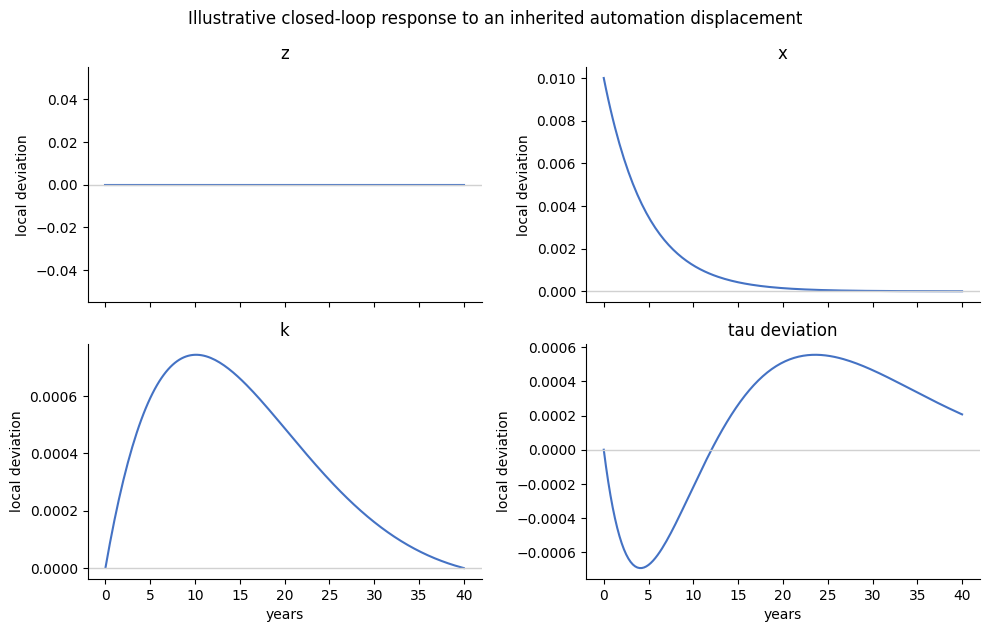

Closed-loop eigenvalues: `-0.076028+0.078265i, -0.076028-0.078265i, -0.210721+0.000000i, -0.210721+0.000000i`. All real parts are negative in this frozen local system.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

system = snapshot["closed_loop_system"]
coordinates = system["coordinates"]
matrix = np.array(system["matrix"], dtype=float)
eigenvalues, eigenvectors = np.linalg.eig(matrix)
inverse_eigenvectors = np.linalg.inv(eigenvectors)

horizons = np.linspace(0.0, 40.0, 161)
initial = np.zeros(4)
initial[coordinates.index("x")] = 0.01
paths = np.array(
    [
        np.real_if_close(
            eigenvectors @ np.diag(np.exp(eigenvalues * horizon))
            @ inverse_eigenvectors @ initial
        ).real
        for horizon in horizons
    ]
)

fig, axes = plt.subplots(2, 2, figsize=(10.0, 6.4), sharex=True)
for index, (axis, coordinate) in enumerate(zip(axes.flat, coordinates)):
    axis.plot(horizons, paths[:, index], color="#4472C4")
    axis.axhline(0, color="0.82", linewidth=1)
    axis.set_title(coordinate.replace("_", " "))
    axis.set_ylabel("local deviation")
    axis.spines[["top", "right"]].set_visible(False)
for axis in axes[-1, :]:
    axis.set_xlabel("years")
fig.suptitle("Illustrative closed-loop response to an inherited automation displacement")
plt.tight_layout()
plt.show()

display(
    Markdown(
        "Closed-loop eigenvalues: `"
        + ", ".join(f"{value.real:.6f}{value.imag:+.6f}i" for value in eigenvalues)
        + "`. All real parts are negative in this frozen local system."
    )
)

## The repaired claim-access interpretation

The public corrected findings report that the full-access/no-claim worker-consumption
gap after the run's automation innovation is `2.752428e-05` at every one of its 161
reported horizons, equal to numerical tolerance. The earlier description of a sign
flip was wrong. The raw IRF rows are not tracked upstream and are intentionally not
republished here; this notebook exposes only the correction already in the public
findings file.

The structural explanation is local: a pure net-worth payoff with no state displacement
adds permanently to comprehensive resources in the linearized system. This remains an
exploratory interpretation, not a finite-risk welfare conclusion.

## Economic interpretation and limitation

The local response makes the timing distinction concrete: inherited state variables
move continuously, while feedback gradually returns the system toward its steady state.
The risky-claim calculation is a separate leading-small-risk block whose fiscal hedge
substantially offsets return demand at the illustrative anchor.

Close residuals and stable eigenvalues establish internal consistency for this local
system. They do not certify global feasibility, off-branch behavior, an optimal nonlinear
policy, or a quantitative welfare claim. CS001 is draft and unfingerprinted, so every
displayed number remains `exploratory_only`.

## Reproduce and trace

- Source: [`tai-public-finance` at public container commit `971cab1`](https://github.com/Nathan-Barnard/tai-public-finance/tree/971cab12986bce99c23a291fd62a5cde66ffa01a)
- Run implementation: [`d876a61`](https://github.com/Nathan-Barnard/tai-public-finance/tree/d876a61ef593737c2cfbd6f758192c0f390318ab)
- Run: `RUN-20260901T194938Z-CS001-d876a61e-01`
- Objects: CP001, CA001, draft CS001
- Environment: upstream `uv.lock`; Python 3.13.5, NumPy 2.5.2, SciPy 1.18.1, Matplotlib 3.11.1, FP64 CPU
- Public export: `notebooks/data/cs001_lq_snapshot.json`; every source artifact is tracked upstream and hash-identified

From the run commit, execute `uv sync` and then
`uv run python -m tai_public_finance.cs001_lq_anchor.cli --config configs/cs001/lq_farhi_smoke.json --output-dir outputs/cs001-lq-anchor-baseline-repair-01 --run-id RUN-20260901T194938Z-CS001-d876a61e-01`. Rebuild the compact export with `scripts/refresh_frozen_exports.py`, then re-run this notebook.